# Praktikum 12: RK Verfahren für Systeme von gDgl

In [43]:
import numpy as np
import matplotlib.pyplot as plt

generell: <br>
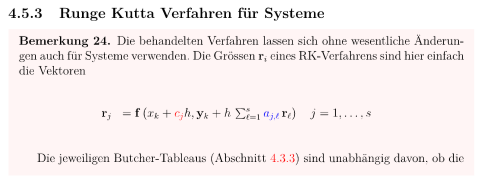

Explizit Euler, Explizit Trapezmethode (Heun):<br>
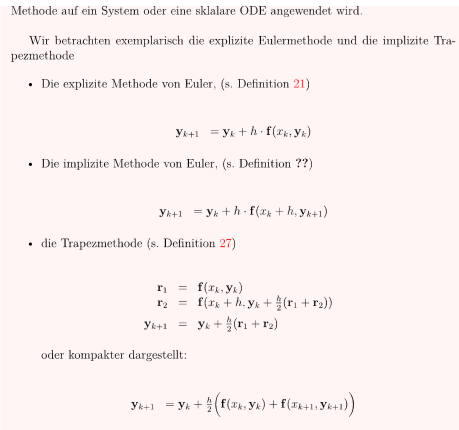

Heun Dummy code aus Skript:<br>
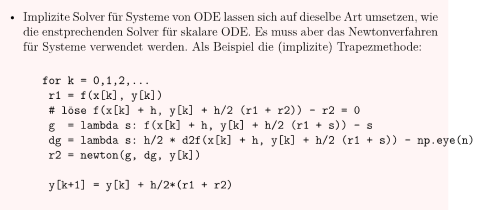



#RK4 für Systeme<br>
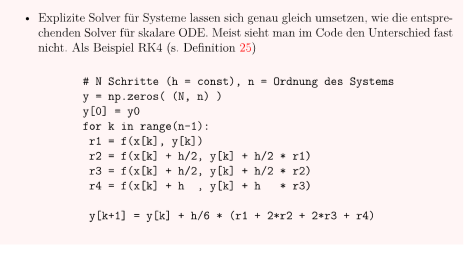

In [44]:
# Implztite Mittelpunktsregel für Systeme
# implizite Mittelpunktsregel
def Mittelpunktsregel_Impl_Systems(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    r = f(x0, y0) # erster Startwert
    while x[-1] < xn - h / 2:
        # r1 = f(x+h/2, y+h/2*r1)
        g  = lambda r: f(x[-1] + h/2, y[-1] + h/2 * r) - r
        dg = lambda r: h/2 * d2f(x[-1] + h/2, y[-1] + h/2 * r) - np.eye(dim)
        r = newtonSystems(g, dg, r)
        y.append(y[-1] + h * r)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

# Newtonverfahren für Systeme

In [45]:
# %% Newtonverfahren für Systeme
def newtonSystems(g, dg, r, tol = 1e-10, maxStep = 100):
    step = 0
    res = np.linalg.norm(g(r))
    while res > tol and step < maxStep:
        delta = np.linalg.solve(dg(r), g(r)) #...
        r -= delta        
        res = np.linalg.norm(g(r))        
        step += 1        
    assert(step < maxStep)        
    return r

# Explizites + Implizites Eulerverfahren

In [46]:
# explizites Eulerverfahren
def eulerExplizit_Systems(f, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        y.append(y[-1] + h * f(x[-1], y[-1]))
        x.append(x[-1] + h)
    return np.array(x), np.array(y)

# implizites Eulerverfahren
def eulerImplizit_Systems(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        g  = lambda s: y[-1] + h * f(x[-1], s) - s
        dg = lambda s: h * d2f(x[-1], s) - np.eye(dim)
        r = y[-1].copy()
        s = newtonSystems(g, dg, r)
        y.append(s)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

# RK4 (mit Schrittweitensteuerung)

In [47]:
# Ein Schritt mit RK 4
def RK4step_Systems(x, y, f, h):
    r1 = f(x, y)
    r2 = f(x + h/2, y + h/2 * r1)
    r3 = f(x + h/2, y + h/2 * r2)
    r4 = f(x + h,   y + h   * r3)

    return y + h/6 * (r1 + 2 * r2 + 2 * r3 + r4)
    
def RK4_Schrittweitensteuerung_Systems(f, x0, y0, xn, tol = 1e-5):
    p = 4  # Fehlerordnung für RK 4
    h = (xn - x0) / 100 # Startwert für h
    rho = 0.9 # Sicherheitsfaktor
    
    x = [x0]
    y = [y0]

    while (x[-1] < xn - 1e-10):

        
        y1 = RK4step_Systems(x[-1], y[-1], f, h)
    
        y12 = RK4step_Systems(x[-1],       y[-1], f, h / 2)
        y22 = RK4step_Systems(x[-1] + h/2, y12,   f, h / 2)
    
        eta = 10 * np.linalg.norm(y1 - y22) / (1 - 2**(-p)) # zusätzlicher Sicherheitsfaktor in der Fehlerschätzung...

        if (eta < tol):
            x.append(x[-1] + h)
            y.append(y22) # wir nehmen den besseren Wert...
            
        h *= rho * (tol / (eta + 1e-5*tol))**(1/(p+1)) # Schrittweite wird in jedem Fall angepasst
        h = min(h, xn - x[-1]) # damit sollten wir die Endstelle nicht überschreiten

    return np.array(x), np.array(y)

Angewendet auf Federdämpfersystem:

Darstellung :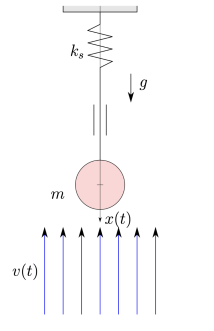<br>

Parameter: 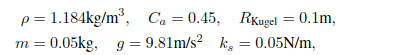 <br>

Gleichungen: 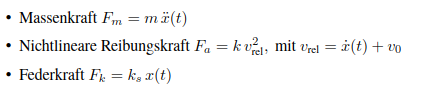 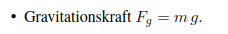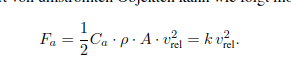<br>


In [ ]:
##Parameter
p = 1.184 #kg/m3
Ca = 0.45
RKugel = 0.1 #m
m = 0.05 #kg
g = 9.81 #m/s2
ks = 0.05 #n/m FEDERKOONSTANTE
v0 = 0



vLuft = 2 #EINSTELLBAR!
h = 0.01  # Schrittweite einstellbar


#Berechnungen
Fg = m * g
AKugel = np.pi * RKugel**2  ## Kugel
k = 0.5 * Ca * p * AKugel  #  Luftwiderstandsfaktor 



# Anfangswerte definieren, x und v sind 0
y0 = np.array([0.0, 0.0])



# --- Definition des Systems ---
# Hilfe von chatgpt

def f(t, y):
    """
    Das System 1. Ordnung für die numerischen Verfahren.
    y[0] = x (Ort)
    y[1] = v (Geschwindigkeit)
    """

    # y[0] ist Ort x, y[1] ist Geschwindigkeit v
    x = y[0] 
    v = y[1]

    dx1 = v # Ort Abgeleitet ist geschwindigkeit---------einmal abgeleitetet


    v_rel = v + v0

    # hilfe chatgpt
    dx2 = g - (ks/m) * x - (k/m) * np.sign(v_rel) * v_rel**2 # Ort zweimal Abgeleitet ist Beschleunigung---------zweimal abgeleitetet

    dy1= dx1
    dy2 = dx2
    return np.array([dy1, dy2])
